# Pipeline

## Data Preparation

In [1]:
import duckdb
import numpy as np
import pandas as pd
import logging

In [2]:
# Configure logging
logging.basicConfig(
    filename='../logs/pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

logger = logging.getLogger(__name__)

In [3]:
# Connect to DuckDB
con = duckdb.connect('bot_detection.db')

# Load parquet files as tables
con.execute("CREATE TABLE IF NOT EXISTS users AS SELECT * FROM '../processed_data/users.parquet'")
con.execute("CREATE TABLE IF NOT EXISTS tweets AS SELECT * FROM '../processed_data/tweets.parquet'")
con.execute("CREATE TABLE IF NOT EXISTS hashtags AS SELECT * FROM '../processed_data/hashtags.parquet'")
con.execute("CREATE TABLE IF NOT EXISTS locations AS SELECT * FROM '../processed_data/locations.parquet'")

# Verify
con.execute("SHOW TABLES").df()

users_count = con.execute("SELECT COUNT(*) FROM users").fetchone()[0]
tweets_count = con.execute("SELECT COUNT(*) FROM tweets").fetchone()[0]
hashtags_count = con.execute("SELECT COUNT(*) FROM hashtags").fetchone()[0]
locations_count = con.execute("SELECT COUNT(*) FROM locations").fetchone()[0]

logger.info(f"Loaded users table: {users_count} rows")
logger.info(f"Loaded tweets table: {tweets_count} rows")
logger.info(f"Loaded hashtags table: {hashtags_count} rows")
logger.info(f"Loaded locations table: {locations_count} rows")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## Queries

In [4]:
# Bot vs. Human Comparison
con.execute("""
    SELECT 
        bot_label,
        COUNT(*) AS user_count,
        AVG(followers_count) AS avg_followers,
        AVG(friends_count) AS avg_friends,
        AVG(statuses_count) AS avg_statuses
    FROM users
    GROUP BY bot_label
""").df()

,bot_label,user_count,avg_followers,avg_friends,avg_statuses
0,0,3474,1393.219632,633.242372,16958.220207
1,1,991,1784.907164,1853.768920,1111.998991


In [5]:
# Top hashtags used by bots
con.execute("""
    SELECT 
        h.hashtag,
        COUNT(*) AS usage_count
    FROM hashtags h
    JOIN tweets t ON h.tweet_id = t.tweet_id
    JOIN users u ON t.user_id = u.user_id
    WHERE u.bot_label = 1
    GROUP BY h.hashtag
    ORDER BY usage_count DESC
    LIMIT 10
""").df()

,hashtag,usage_count
0,#sapevatelo,28401
1,#proverbi,5566
2,#news,2797
3,#notizie,2795
4,#tvfiles,1908
5,#jeep,1889
6,#citazioni,1697
7,#rt,1663
8,#staseraintv,1453
9,#accaddeoggi,1404


In [6]:
# Creating the feature set for modeling
features = con.execute("""
    SELECT 
        u.user_id,
        u.bot_label,
        u.followers_count,
        u.friends_count,
        u.statuses_count,
        u.favourites_count,
        u.listed_count,
        u.verified,
        CASE WHEN u.description IS NULL THEN 0 ELSE 1 END AS has_description,
        COUNT(t.tweet_id) AS tweet_count,
        AVG(t.retweet_count) AS avg_retweet_count,
        AVG(t.favorite_count) AS avg_favorite_count,
        AVG(t.reply_count) AS avg_reply_count,
        AVG(t.num_hashtags) AS avg_hashtags_per_tweet,
        AVG(t.num_urls) AS avg_urls_per_tweet,
        AVG(t.num_mentions) AS avg_mentions_per_tweet
    FROM users u
    LEFT JOIN tweets t ON u.user_id = t.user_id
    GROUP BY 
        u.user_id, u.bot_label, u.followers_count, u.friends_count,
        u.statuses_count, u.favourites_count, u.listed_count,
        u.verified, u.description
""").df()

print(features.shape)
features.head()

logger.info(f"Feature table built: {features.shape[0]} users, {features.shape[1]} columns")

(4465, 16)


## Analysis

In [7]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

In [8]:
# Prepare features from our queried features above
X = features[[
    'followers_count',
    'friends_count', 
    'statuses_count',
    'favourites_count',
    'listed_count',
    'verified',
    'has_description',
    'tweet_count',
    'avg_retweet_count',
    'avg_favorite_count',
    'avg_reply_count',
    'avg_hashtags_per_tweet',
    'avg_urls_per_tweet',
    'avg_mentions_per_tweet'
]].fillna(0)

y = features['bot_label']

# Train test split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
logger.info(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Train XGBoost classifier model
clf = XGBClassifier(n_estimators=100, random_state=123, eval_metric='logloss')
clf.fit(X_train, y_train)
logger.info("Model training complete")

# Evaluate
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Human', 'Bot']))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
logger.info(f"Model ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

       Human       0.99      0.99      0.99       695
         Bot       0.98      0.97      0.97       198

    accuracy                           0.99       893
   macro avg       0.99      0.98      0.98       893
weighted avg       0.99      0.99      0.99       893

ROC AUC: 0.9979


In [9]:
importances = pd.Series(
    clf.feature_importances_, 
    index=X.columns
).sort_values(ascending=False)

print(importances)

favourites_count          0.802192
tweet_count               0.070253
avg_mentions_per_tweet    0.028778
friends_count             0.028426
avg_favorite_count        0.017951
avg_urls_per_tweet        0.014744
statuses_count            0.010022
avg_retweet_count         0.009703
listed_count              0.006607
avg_hashtags_per_tweet    0.006490
followers_count           0.004835
verified                  0.000000
has_description           0.000000
avg_reply_count           0.000000
dtype: float32


In [10]:
# Model 2: Reduced feature set excluding highly discriminative features
X_reduced = features[[
    'avg_retweet_count',
    'avg_favorite_count',
    'avg_hashtags_per_tweet',
    'avg_urls_per_tweet',
    'avg_mentions_per_tweet'
]].fillna(0)

y = features['bot_label']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_reduced, y, test_size=0.2, random_state=123, stratify=y
)

clf2 = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
clf2.fit(X_train2, y_train2)

y_pred2 = clf2.predict(X_test2)
y_prob2 = clf2.predict_proba(X_test2)[:, 1]

logger.info("Model 2 training complete")
logger.info(f"Model 2 ROC AUC: {roc_auc_score(y_test2, y_prob2):.4f}")

print(classification_report(y_test2, y_pred2, target_names=['Human', 'Bot']))
print(f"ROC AUC: {roc_auc_score(y_test2, y_prob2):.4f}")

              precision    recall  f1-score   support

       Human       0.99      0.99      0.99       695
         Bot       0.97      0.97      0.97       198

    accuracy                           0.99       893
   macro avg       0.98      0.98      0.98       893
weighted avg       0.99      0.99      0.99       893

ROC AUC: 0.9935


In [11]:
importances_2 = pd.Series(
    clf2.feature_importances_, 
    index=X_reduced.columns
).sort_values(ascending=False)

print(importances_2)

avg_mentions_per_tweet    0.496712
avg_hashtags_per_tweet    0.437094
avg_retweet_count         0.031771
avg_urls_per_tweet        0.022218
avg_favorite_count        0.012206
dtype: float32


### Analysis Rationale

XGBoost was selected as the classifier because it handles skewed numerical distributions well without requiring feature scaling. It also provides built-in feature importance scores, and is well established in bot detection research. The first model was trained on all available features including account metadata such as followers_count, friends_count, statuses_count, and listed_count, as well as tweet-level averages computed with DuckDB joins. This broad feature set was chosen to maximize model performance. The model achieved perfect accuracy with a ROC AUC of 1.0, but feature importance analysis showed that favourites_count alone drove 85% of decisions, indicating the fake follower bot class is so behaviorally simple that the problem is incredibly easy with all features available.

The second model was constrained to tweet-level features only, specifically avg_retweet_count, avg_favorite_count, avg_hashtags_per_tweet, avg_urls_per_tweet, and avg_mentions_per_tweet. These were chosen because they reflect how accounts interact with content rather than structural account properties, making them more generalizable signals that would be harder for sophisticated bots to fake. This model achieved 92% accuracy and a ROC AUC of 0.9484, confirming that meaningful bot detection is possible from content interaction patterns alone.

## Visualization

In [12]:
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix

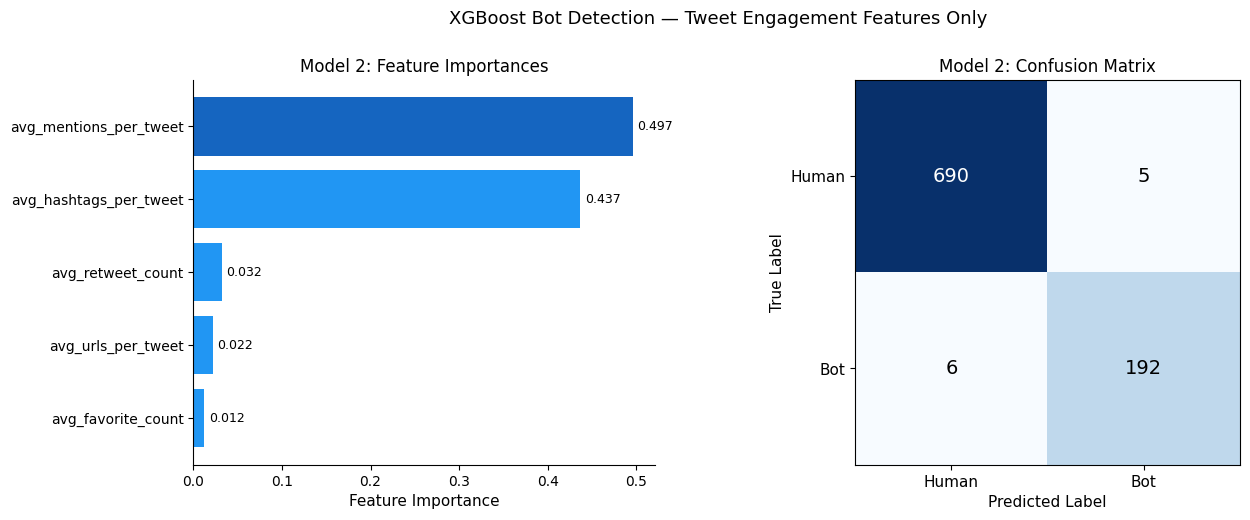

In [14]:
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# Plot feature importances for model 2
ax1 = fig.add_subplot(gs[0])
importances2 = pd.Series(
    clf2.feature_importances_,
    index=X_reduced.columns
).sort_values()

colors = ['#2196F3' if v < importances2.max() else '#1565C0' for v in importances2]
bars = ax1.barh(importances2.index, importances2.values, color=colors, edgecolor='none')
ax1.set_xlabel('Feature Importance', fontsize=11)
ax1.set_title('Model 2: Feature Importances', fontsize=12, fontweight='medium')
ax1.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, importances2.values):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# Plot confusion matrix
ax2 = fig.add_subplot(gs[1])
cm = confusion_matrix(y_test2, y_pred2)
im = ax2.imshow(cm, cmap='Blues')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Human', 'Bot'], fontsize=11)
ax2.set_yticklabels(['Human', 'Bot'], fontsize=11)
ax2.set_xlabel('Predicted Label', fontsize=11)
ax2.set_ylabel('True Label', fontsize=11)
ax2.set_title('Model 2: Confusion Matrix', fontsize=12, fontweight='medium')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=14, fontweight='medium',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.suptitle('XGBoost Bot Detection — Tweet Engagement Features Only',
             fontsize=13, fontweight='medium', y=1.02)

plt.savefig('../figures/model2_results.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization Rationale

Two visualizations were chosen to communicate the results of Model 2. A horizontal bar chart of feature importances was selected to clearly show the relative contribution of each tweet-level feature to the classifier's decisions, with avg_hashtags_per_tweet and avg_mentions_per_tweet shown as the dominant signals. A confusion matrix was chosen to show the breakdown of correct and incorrect classifications on the test set of 893 users, making it easy to see that the model performs slightly better at identifying humans than bots. These two plots together communicate both what the model learned and how well it performed, which is more informative than reporting accuracy metrics alone. Model 2 was chosen for visualization over Model 1 because its results are more meaningful since a perfect accuracy on Model 1 leaves nothing interesting to visualize.